device: cpu


100.0%
100.0%
100.0%
100.0%


epoch 1: train 1.0964 test 0.4580
epoch 2: train 0.3882 test 0.3223
epoch 3: train 0.3103 test 0.2801
epoch 4: train 0.2723 test 0.2502
epoch 5: train 0.2439 test 0.2286
epoch 6: train 0.2235 test 0.2105
epoch 7: train 0.2030 test 0.1946
epoch 8: train 0.1876 test 0.1829
epoch 9: train 0.1733 test 0.1719
epoch 10: train 0.1618 test 0.1639
epoch 11: train 0.1506 test 0.1544
epoch 12: train 0.1420 test 0.1478
epoch 13: train 0.1342 test 0.1426
epoch 14: train 0.1270 test 0.1363
epoch 15: train 0.1202 test 0.1314
epoch 16: train 0.1132 test 0.1268
epoch 17: train 0.1075 test 0.1231
epoch 18: train 0.1028 test 0.1199
epoch 19: train 0.0980 test 0.1159
epoch 20: train 0.0935 test 0.1139
epoch 21: train 0.0899 test 0.1130
epoch 22: train 0.0859 test 0.1105
epoch 23: train 0.0825 test 0.1079
epoch 24: train 0.0787 test 0.1079
epoch 25: train 0.0759 test 0.1039
epoch 26: train 0.0723 test 0.1021
epoch 27: train 0.0699 test 0.1021
epoch 28: train 0.0671 test 0.1012
epoch 29: train 0.0651 test 0

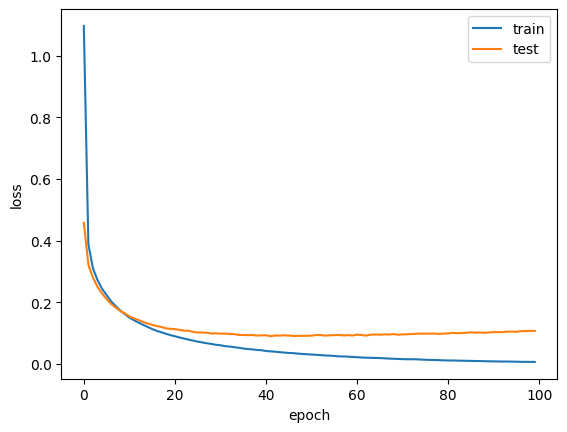

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print(torch.cuda.get_device_name(0))

# Load raw MNIST once
train_raw = datasets.MNIST("./data", train=True, download=True)
test_raw = datasets.MNIST("./data", train=False, download=True)

# Convert once, normalise once, move to GPU once
X_train = train_raw.data.float().div(255.0)
X_train = (X_train - 0.1307) / 0.3081
X_train = X_train.view(-1, 28 * 28).to(device)

y_train = train_raw.targets.to(device)

X_test = test_raw.data.float().div(255.0)
X_test = (X_test - 0.1307) / 0.3081
X_test = X_test.view(-1, 28 * 28).to(device)

y_test = test_raw.targets.to(device)

model = nn.Sequential(
    nn.Linear(28 * 28, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

epochs = 100
batch_size = 2048

train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()

    perm = torch.randperm(X_train.size(0), device=device)
    total_loss = 0.0

    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i + batch_size]
        x = X_train[idx]
        y = y_train[idx]

        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

        total_loss += loss.detach() * x.size(0)

    train_loss = (total_loss / X_train.size(0)).item()
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        test_loss = loss_fn(model(X_test), y_test).item()
    test_losses.append(test_loss)

    print(f"epoch {epoch+1}: train {train_loss:.4f} test {test_loss:.4f}")

plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()